## Using Tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers, models
import matplotlib.pyplot as plt

c:\Users\BAPS\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\BAPS\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\BAPS\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

In [2]:
import numpy as np
import cv2

In [ ]:
# Downloading the CIFAR10 dataset which is prebuilt in Keras , you just have to download it
# It downloads the dataset only once and from the next time just loads the data from the location it is saved in system
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()
#C:\Users\BAPS\.keras\datasets Dataset is stored at this location
"""There are 50k images in the dataset"""

'There are 50k images in the dataset'

In [4]:
class_names=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship",'truck']

In [30]:
"""sharpening_kernel = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
])
# Used for sharpening the whole dataset , though for this instance we shouldn't do this as we have to normalize the dataset and also is very time taking process
for i in range(len(x_train)):
    x_train[i]=cv2.filter2D(x_train[i],-1,sharpening_kernel)
    print("Image",i,"has been sharpened!!")"""

'sharpening_kernel = np.array([\n    [-1, -1, -1],\n    [-1,  9, -1],\n    [-1, -1, -1]\n])\n# Used for sharpening the whole dataset , though for this instance we shouldn\'t do this as we have to normalize the dataset and also is very time taking process\nfor i in range(len(x_train)):\n    x_train[i]=cv2.filter2D(x_train[i],-1,sharpening_kernel)\n    print("Image",i,"has been sharpened!!")'

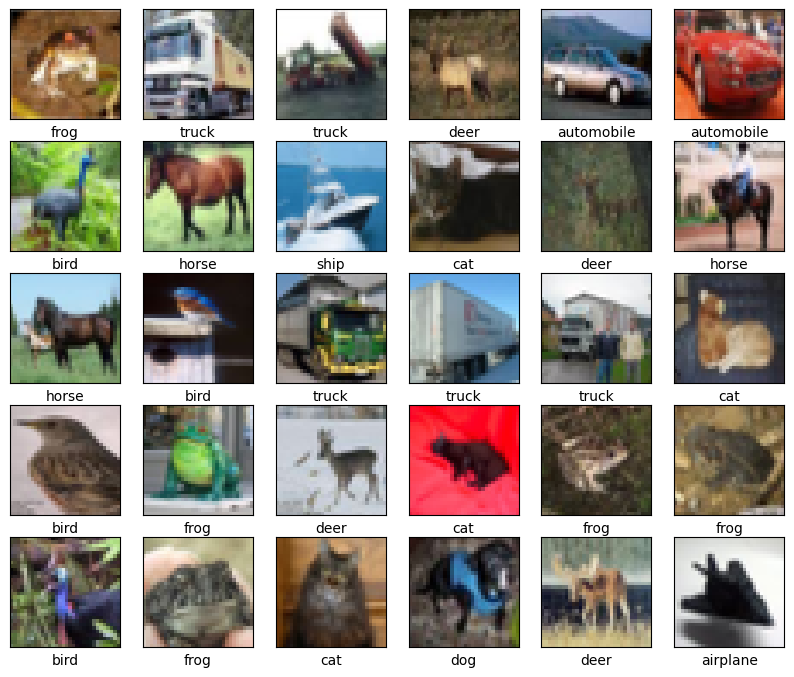

In [5]:
plt.figure(figsize=(10,10))
for i in range(30):
# The number passed in range should be less than or equals to the product of two numbers passed in the subplot
    plt.subplot(6,6,i+1)
    plt.xticks([]) 
    """plt.xticks(data,labels,rotation) -> sets the labels for the x axis , like if we want we can keep some labels with their corresponding values
    data -> value at that point
    labels -> label name 
    rotation -> the angle of the label"""
    plt.yticks([])
    """plt.yticks() -> sets the labels for the y axis"""
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]]) # Shows the image label in x-axis
plt.show()

In [6]:
# Normalize the data 
x_train,x_test=x_train/255,x_test/255

### Creating the Convolutional Layer

In [27]:
model= models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)))
"""
model.add() -> adds the layers in an sequential model 
"""
"""
layers.Conv2D(number_of_filters,filter_size,stride,padding,activation_function,inputshape)
arg1 -> number of filters the layer should have
arg2 -> size of these filters
arg3 -> step by which the filter should jump
arg4 -> padding of the imput (either "same" or "valid")
arg5 -> activation functions to be used
arg6 -> input shape to be expected by the model (only for the first layer)
"""
model.add(layers.MaxPool2D(2,2))
"""
layers.MaxPool2D(pool_size,stride,padding)
arg1 -> size of the pool kernel
arg2 -> step by which pool should move
arg3 -> padding of the imput (either "same" or "valid")
"""
model.add(layers.Conv2D(32,(3,3),activation="relu"))
model.add(layers.MaxPool2D(2,2))
model.add(layers.Conv2D(24,(3,3),activation="relu"))

In [28]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 24)       │         6,936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,080 (66.72 KB)

 Trainable params: 17,080 (66.72 KB)

 Non-trainable params: 0 (0.00 B)

#### Flatten Layer and fully connected 

In [29]:
model.add(layers.Flatten())
model.add(layers.Dense(16,activation="relu"))
model.add(layers.Dense(10))     # This has to be equal to the number outputs 

In [30]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 24)       │         6,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         6,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,410 (91.45 KB)

 Trainable params: 23,410 (91.45 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling of the model and Traning 

In [31]:
model.compile(optimizer="adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=["accuracy"])

history=model.fit(x_train,y_train,epochs=30,validation_data=(x_test,y_test))
print(history)

# Untill you are not re-defining the model again, the weights of the previous model would be saved and when you try to compile it again, it will use weights of previous model

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3840 - loss: 1.6677 - val_accuracy: 0.4963 - val_loss: 1.3782
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5315 - loss: 1.3034 - val_accuracy: 0.5628 - val_loss: 1.2562
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5919 - loss: 1.1501 - val_accuracy: 0.6094 - val_loss: 1.1103
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6244 - loss: 1.0654 - val_accuracy: 0.6300 - val_loss: 1.0528
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6480 - loss: 1.0005 - val_accuracy: 0.6234 - val_loss: 1.0506
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6633 - loss: 0.9568 - val_accuracy: 0.6401 - val_loss: 1.0408
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6756 - loss: 0.9216 - val_accuracy: 0.6575 - val_loss: 0.9814
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6874 - loss: 0

In [32]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
accuracy*=100
print(f"Test Accuracy: {accuracy:.2f}")
print("Loss -> ",loss)

Test Accuracy: 70.34
Loss ->  0.8949187397956848


In [46]:
from keras.preprocessing import image

In [87]:
import os 
os.getcwd()
os.chdir(r"c:\\Users\\BAPS\\Desktop\\Python")

In [88]:
pred_img=image.load_img(r"Images\plane_img.jpg",target_size=(32,32))
original_img=cv2.imread(r"Images\plane_img.jpg",-1)

In [89]:
pred_img=image.img_to_array(pred_img)
pred_img.shape

(32, 32, 3)

In [90]:
test_img=np.expand_dims(pred_img,axis=0)
test_img.shape
test_img=test_img/255

In [91]:
result=model.predict(test_img)
pred_class=np.argmax(result)
cv2.putText(original_img,class_names[pred_class],(50,30),cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,0),cv2.LINE_4)
cv2.imshow("Predicted Image ",original_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


## Using Pytorch

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset=torchvision.datasets.CIFAR10(root='C:/Users/BAPS/.keras/datasets/cifar-10-batches-py-target',train=True,download=False,transform=transform)

trainloader=torch.utils.data.DataLoader(trainset,batch_size=4,shuffle=True,num_workers=2)

testset=torchvision.datasets.CIFAR10(root="C:/Users/BAPS/.keras/datasets/cifar-10-batches-py-target",train=False,download=False,transform=transform)

testloader=torch.utils.data.DataLoader(testset,batch_size=4,shuffle=False,num_workers=2)

classess=("plane","car","bird","cat","deer","dog","frog","horse","ship","truck")

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1=nn.Conv2d(3,6,5)
        self.pool=nn.MaxPool2d(2,1)
        self.conv2=nn.Conv2d(6,16,5)
        self.conv3=nn.Conv2d(4,8,2)
        self.fc1=nn.Linear(16*5*5,120)
        self.fc2=nn.Linear(120,84)
    
    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=self.pool(F.relu(self.conv3(x)))
        x=x.reshape(x.shape[0],-1)
        x=F.relu(self.fc1(x))
        x=self.fc2(x)
        return x    

In [11]:
device="Cuda" if torch.cuda.is_available() else "cpu"

model=CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(4, 8, kernel_size=(2, 2), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
)


In [12]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

In [ ]:
num_epochs=10
for epoch in range(num_epochs):
    print(f"Epoch [{epoch+1}/{num_epochs}]")

    for batch_index,(data,targets) in enumerate(tqdm())